In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#load dataset

In [ ]:
titanic =pd.read_csv("/content/titanic_dataset.csv")

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Make ‘PassengerId’ as the index column

In [ ]:
titanic.set_index("PassengerId", inplace = True)

In [ ]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Check the basic details of the dataset

In [ ]:
titanic.shape

(891, 11)

In [ ]:
titanic.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [ ]:
# drop unwanted columns

titanic = titanic.drop(columns =['Name','Ticket'])

#missing value

In [ ]:
# check missing values

titanic.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


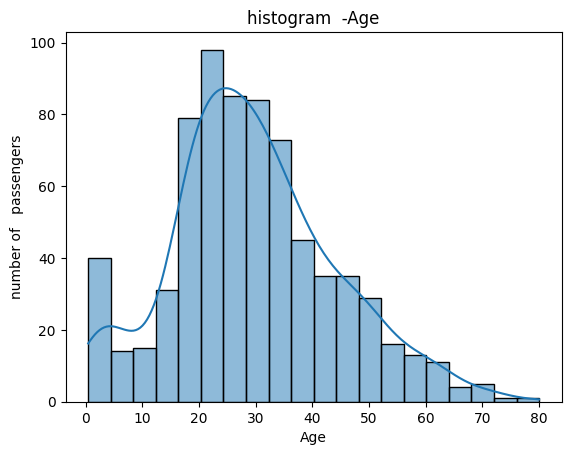

In [ ]:
sns.histplot(titanic['Age'],kde =True)
plt.xlabel("Age")
plt.ylabel("number of   passengers")
plt.title("histogram  -Age")
plt.show()

In [ ]:
# median imputation

titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

In [ ]:
titanic.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [ ]:

titanic.dropna(subset=['Embarked'],inplace = True)

In [ ]:
titanic = titanic.drop("Cabin",axis =1)

In [ ]:
titanic.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# outlier detection

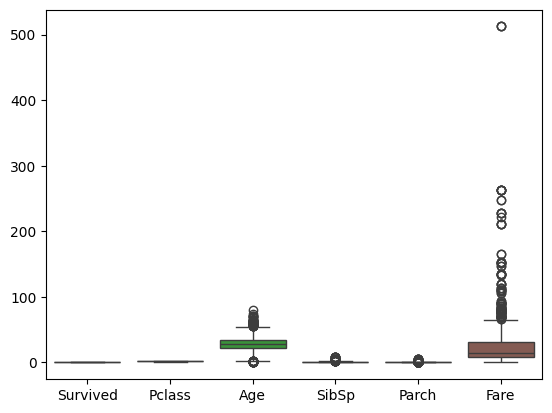

In [ ]:
sns.boxplot(titanic)
plt.show()

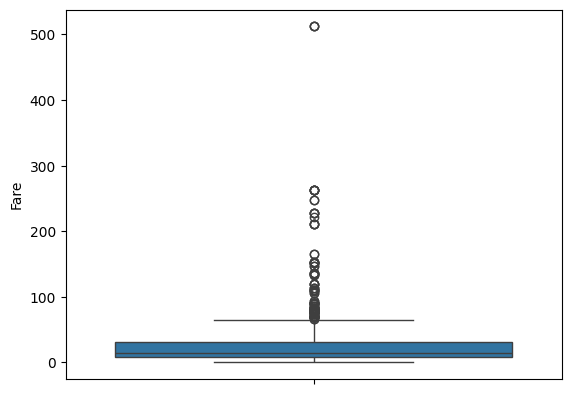

In [ ]:
sns.boxplot(titanic['Fare'])
plt.show()

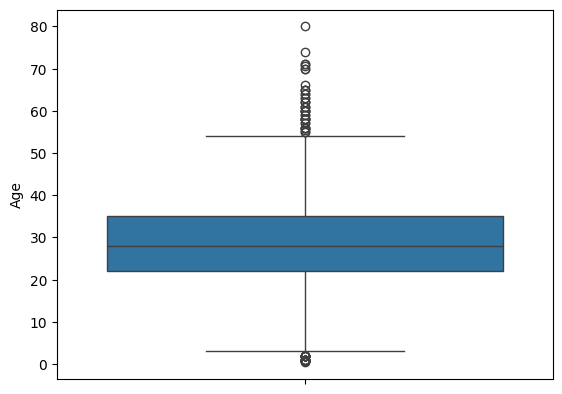

In [ ]:
sns.boxplot(titanic['Age'])
plt.show()

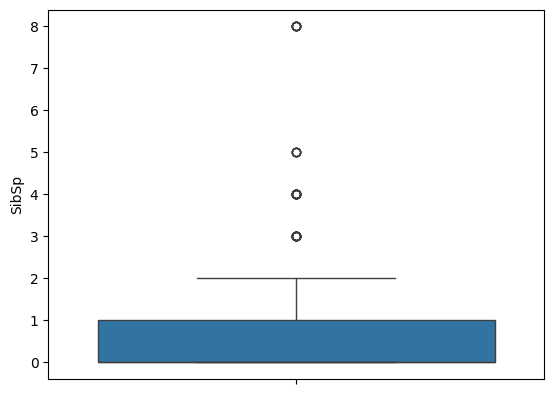

In [ ]:
sns.boxplot(titanic['SibSp'])
plt.show()

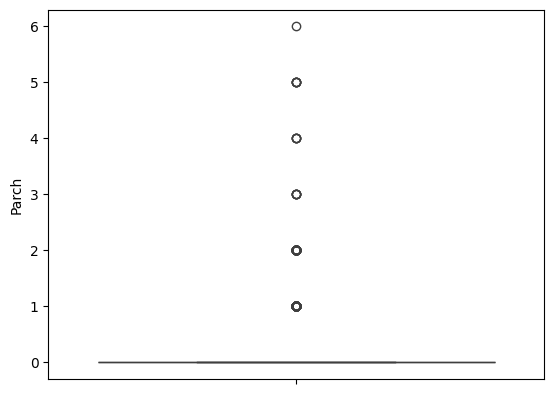

In [ ]:
sns.boxplot(titanic['Parch'])
plt.show()

In [ ]:
# Remove outlier parch ans sibsp
#outlier clipping






In [ ]:
# using iqr method for parch

q1 = titanic['Parch'].quantile(0.25)
q2 = titanic['Parch'].quantile(0.5)
q3 = titanic['Parch'].quantile(0.75)

In [ ]:
print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')

Q1 =0.0
Q2 =0.0
Q3 =0.0


In [ ]:
# minimum value zero aayath kond handle cheyyanda

In [ ]:
q1 = titanic['SibSp'].quantile(0.25)
q2 = titanic['SibSp'].quantile(0.5)
q3 = titanic['SibSp'].quantile(0.75)

In [ ]:
print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')

Q1 =0.0
Q2 =0.0
Q3 =1.0


In [ ]:
q1 = titanic['Age'].quantile(0.25)
q2 = titanic['Age'].quantile(0.5)
q3 = titanic['Age'].quantile(0.75)

In [ ]:
print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')

Q1 =22.0
Q2 =28.0
Q3 =35.0


In [ ]:
IQR = q3 -q1
up_lim = q3+(1.5*IQR)
low_lim = q1 -(1.5*IQR)
print(f'Iqr = {IQR} \n UPPER LIMIT = {up_lim} \n LOWER LIMIT = {low_lim}')

Iqr = 13.0 
 UPPER LIMIT = 54.5 
 LOWER LIMIT = 2.5


In [ ]:
titanic.loc[titanic['Age'] > up_lim, 'Age'] = up_lim
titanic.loc[titanic['Age'] < low_lim, 'Age'] = low_lim

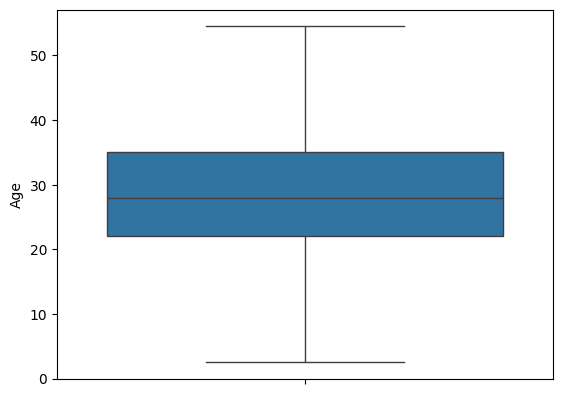

In [ ]:
sns.boxplot(titanic['Age'])
plt.show()

In [ ]:
q1 = titanic['Fare'].quantile(0.25)
q2 = titanic['Fare'].quantile(0.5)
q3 = titanic['Fare'].quantile(0.75)

In [ ]:
print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')
IQR = q3 -q1
up_lim = q3+(1.5*IQR)
low_lim = q1 -(1.5*IQR)
print(f'Iqr = {IQR} \n UPPER LIMIT = {up_lim} \n LOWER LIMIT = {low_lim}')


Q1 =7.8958
Q2 =14.4542
Q3 =31.0
Iqr = 23.1042 
 UPPER LIMIT = 65.6563 
 LOWER LIMIT = -26.7605


In [ ]:
titanic.loc[titanic['Fare'] > up_lim, 'Fare'] = up_lim
titanic.loc[titanic['Fare'] < low_lim, 'Fare'] = low_lim

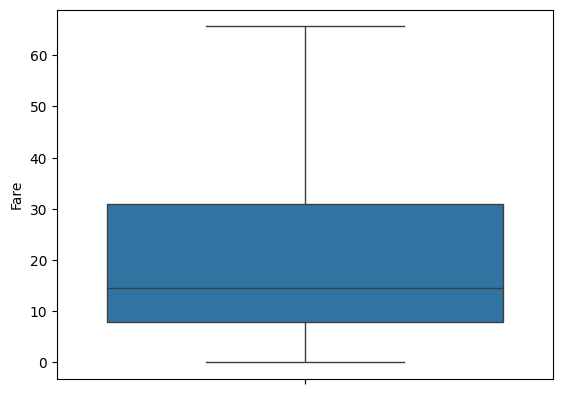

In [ ]:
sns.boxplot(titanic['Fare'])
plt.show()

# Encoding

In [ ]:
titanic.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [ ]:
# categorical columns to numerical columns

titanic['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
titanic = pd.get_dummies(titanic,dtype='int',drop_first=True)
titanic

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1
2,1,1,38.0,1,0,65.6563,0,0,0
3,1,3,26.0,0,0,7.9250,0,0,1
4,1,1,35.0,1,0,53.1000,0,0,1
5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
887,0,2,27.0,0,0,13.0000,1,0,1
888,1,1,19.0,0,0,30.0000,0,0,1
889,0,3,28.0,1,2,23.4500,0,0,1


In [ ]:
titanic.dtypes

,0
Survived,int64
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,int64
Embarked_Q,int64
Embarked_S,int64


# test train split

In [ ]:
from sklearn.model_selection import train_test_split

y = titanic['Survived']
x = titanic.drop('Survived',axis=1)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols =['Age','Fare']
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] =scaler.transform(x_test[num_cols])

In [ ]:
x_test

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
282,3,-0.098151,0,0,-0.789193,1,0,1
436,1,-1.246209,1,2,2.048652,0,0,1
40,3,-1.246209,1,0,-0.622881,0,0,0
419,2,0.065857,0,0,-0.536556,1,0,1
586,1,-0.918193,0,2,2.048652,0,0,1
...,...,...,...,...,...,...,...,...
434,3,-1.000197,0,0,-0.824994,1,0,1
808,3,-0.918193,0,0,-0.793082,0,0,1
26,3,0.721890,1,5,0.366195,0,0,1


In [ ]:
y_test

,Survived
PassengerId,
282,0
436,1
40,1
419,0
586,1
...,...
434,0
808,0
26,1


In [53]:
# creating a copy of my features
x1=x.copy()
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for i in ['Age','Fare']:
  x1[i] = scaler.fit_transform(x1[[i]])
  x1.describe()

# scaled x_train1 and x_test1
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42, stratify=y)

# non scaled x_train1 and x_test1

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(x_train,y_train)
y_pred_lr_model =lr_model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix,precision_score
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import recall_score

In [ ]:
print(confusion_matrix(y_test,y_pred_lr_model))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_lr_model))
print("Precision is : ",precision_score(y_test,y_pred_lr_model))
print("Recall is : ",recall_score(y_test,y_pred_lr_model))
print("F1 score is : ",f1_score(y_test,y_pred_lr_model))

[[88 21]
 [16 53]]
Accuracy is :  0.7921348314606742
Precision is :  0.7162162162162162
Recall is :  0.7681159420289855
F1 score is :  0.7412587412587412


#logistics regression scaled data

In [54]:
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(x_train1,y_train)
y_pred_lr_model =lr_model.predict(x_test1)

In [55]:
print(confusion_matrix(y_test,y_pred_lr_model))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_lr_model))
print("Precision is : ",precision_score(y_test,y_pred_lr_model))
print("Recall is : ",recall_score(y_test,y_pred_lr_model))
print("F1 score is : ",f1_score(y_test,y_pred_lr_model))

[[98 12]
 [21 47]]
Accuracy is :  0.8146067415730337
Precision is :  0.7966101694915254
Recall is :  0.6911764705882353
F1 score is :  0.7401574803149606


# Knn modelling

In [ ]:
# finding the optimum k value
from sklearn.neighbors import KNeighborsClassifier

acc_score =[]
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(x_train,y_train)
  y_pred_knn = knn.predict(x_test)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

In [ ]:
acc_score

[0.7752808988764045,
 0.7752808988764045,
 0.7696629213483146,
 0.7696629213483146,
 0.7808988764044944,
 0.7808988764044944,
 0.7921348314606742]

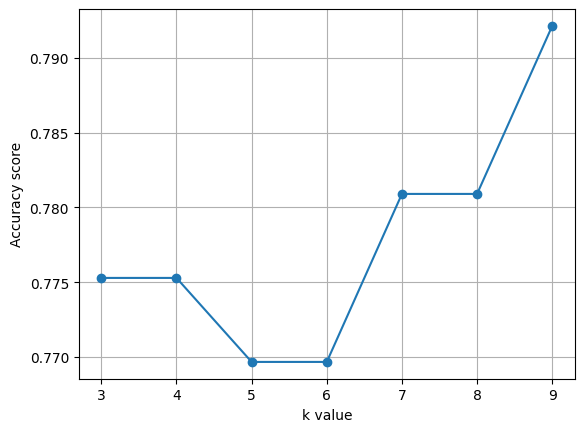

In [ ]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy score')
plt.grid()

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(x_train,y_train)
y_pred_knn = knn.predict(x_test)

print(confusion_matrix(y_test,y_pred_knn))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_knn))
print("Precision is : ",precision_score(y_test,y_pred_knn))
print("Recall is : ",recall_score(y_test,y_pred_knn))
print("F1 score is : ",f1_score(y_test,y_pred_knn))

[[88 21]
 [16 53]]
Accuracy is :  0.7921348314606742
Precision is :  0.7162162162162162
Recall is :  0.7681159420289855
F1 score is :  0.7412587412587412


# knn model (scaled data)

In [56]:
acc_score =[]
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(x_train1,y_train)
  y_pred_knn = knn.predict(x_test1)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

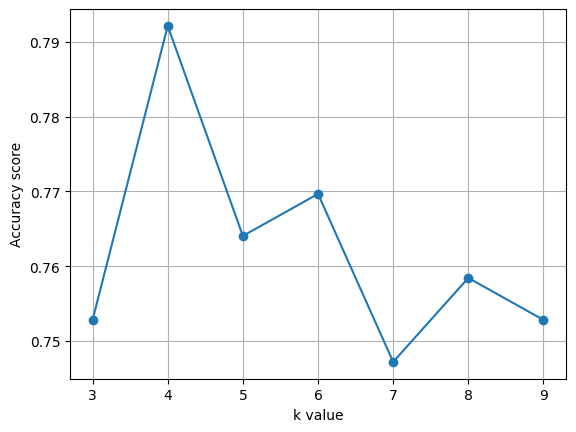

In [57]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy score')
plt.grid()

In [58]:
knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(x_train1,y_train)
y_pred_knn = knn.predict(x_test1)

print(confusion_matrix(y_test,y_pred_knn))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_knn))
print("Precision is : ",precision_score(y_test,y_pred_knn))
print("Recall is : ",recall_score(y_test,y_pred_knn))
print("F1 score is : ",f1_score(y_test,y_pred_knn))

[[89 21]
 [23 45]]
Accuracy is :  0.7528089887640449
Precision is :  0.6818181818181818
Recall is :  0.6617647058823529
F1 score is :  0.6716417910447762


#svm

In [59]:
from sklearn.svm import SVC


In [60]:
svm_linear = SVC(kernel = 'linear')
svm_linear.fit(x_train1,y_train)
y_pred_svm_linear = svm_linear.predict(x_test1)

print(confusion_matrix(y_test,y_pred_svm_linear))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_svm_linear))
print("Precision is : ",precision_score(y_test,y_pred_svm_linear))
print("Recall is : ",recall_score(y_test,y_pred_svm_linear))
print("F1 score is : ",f1_score(y_test,y_pred_svm_linear))

[[94 16]
 [25 43]]
Accuracy is :  0.7696629213483146
Precision is :  0.7288135593220338
Recall is :  0.6323529411764706
F1 score is :  0.6771653543307087


In [62]:
svm_poly = SVC(kernel = 'poly')
svm_poly.fit(x_train1,y_train)
y_pred_svm_poly = svm_poly.predict(x_test1)

print(confusion_matrix(y_test,y_pred_svm_poly))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_svm_poly))
print("Precision is : ",precision_score(y_test,y_pred_svm_poly))
print("Recall is : ",recall_score(y_test,y_pred_svm_poly))
print("F1 score is : ",f1_score(y_test,y_pred_svm_poly))

[[98 12]
 [23 45]]
Accuracy is :  0.8033707865168539
Precision is :  0.7894736842105263
Recall is :  0.6617647058823529
F1 score is :  0.72


In [63]:
svm_rbf = SVC(kernel = 'rbf')
svm_rbf.fit(x_train1,y_train)
y_pred_svm_rbf = svm_rbf.predict(x_test1)

print(confusion_matrix(y_test,y_pred_svm_rbf))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_svm_rbf))
print("Precision is : ",precision_score(y_test,y_pred_svm_rbf))
print("Recall is : ",recall_score(y_test,y_pred_svm_rbf))
print("F1 score is : ",f1_score(y_test,y_pred_svm_rbf))

[[99 11]
 [27 41]]
Accuracy is :  0.7865168539325843
Precision is :  0.7884615384615384
Recall is :  0.6029411764705882
F1 score is :  0.6833333333333333


# Decision tree

In [64]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="entropy",random_state = 42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)

print(confusion_matrix(y_test,y_pred_dt))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_dt))
print("Precision is : ",precision_score(y_test,y_pred_dt))
print("Recall is : ",recall_score(y_test,y_pred_dt))
print("F1 score is : ",f1_score(y_test,y_pred_dt))

[[90 20]
 [19 49]]
Accuracy is :  0.7808988764044944
Precision is :  0.7101449275362319
Recall is :  0.7205882352941176
F1 score is :  0.7153284671532847


In [ ]:
# Random forest

In [65]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion="entropy",random_state = 42)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)

print(confusion_matrix(y_test,y_pred_rf))
print("Accuracy is : " ,accuracy_score(y_test,y_pred_rf))
print("Precision is : ",precision_score(y_test,y_pred_rf))
print("Recall is : ",recall_score(y_test,y_pred_rf))
print("F1 score is : ",f1_score(y_test,y_pred_rf))

[[96 14]
 [20 48]]
Accuracy is :  0.8089887640449438
Precision is :  0.7741935483870968
Recall is :  0.7058823529411765
F1 score is :  0.7384615384615385
